# Model Training - Baseline (Logistic Regression)
Simple logistic regression to set our baseline model.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv('../data/train_processed.csv')

FEATURES = ['Pclass', 'Sex_encoded', 'Age', 'FamilySize', 'IsAlone',
            'LogFare', 'Embarked_encoded', 'Title_encoded', 'AgeBand_encoded']

X = train[FEATURES]
y = train['Survived']

print('X shape:', X.shape)
print('Class balance:', y.value_counts().to_dict())

X shape: (891, 9)
Class balance: {0.0: 549, 1.0: 342}


In [2]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train model
lr = LogisticRegression(random_state=42, max_iter=500)
lr.fit(X_scaled, y)

# Cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr, X_scaled, y, cv=cv, scoring='accuracy')

print(f'CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')
print(f'Individual folds: {cv_scores.round(4)}')

CV Accuracy: 0.8002 (+/- 0.0139)
Individual folds: [0.7933 0.7921 0.7865 0.8034 0.8258]


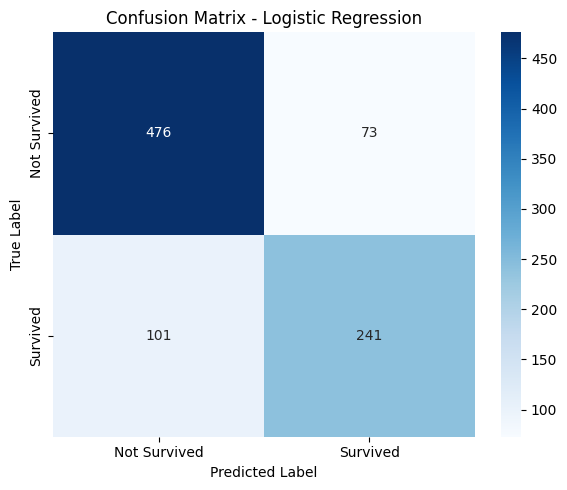

              precision    recall  f1-score   support

Not Survived       0.82      0.87      0.85       549
    Survived       0.77      0.70      0.73       342

    accuracy                           0.80       891
   macro avg       0.80      0.79      0.79       891
weighted avg       0.80      0.80      0.80       891



In [3]:
# Confusion matrix on full training set
y_pred = lr.predict(X_scaled)
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../plots/confusion_matrix_lr.png', dpi=150)
plt.show()

print(classification_report(y, y_pred, target_names=['Not Survived', 'Survived']))

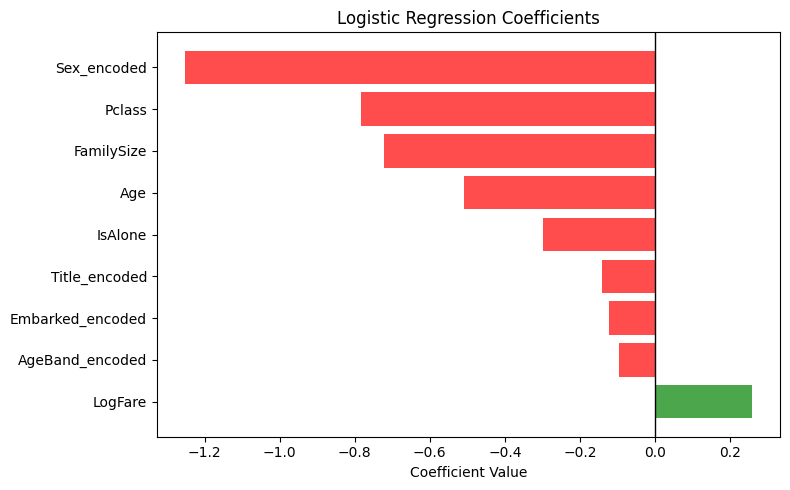


Baseline CV Accuracy: 0.8002


In [4]:
# Feature importance
coeff_df = pd.DataFrame({'Feature': FEATURES, 'Coefficient': lr.coef_[0]})
coeff_df = coeff_df.sort_values('Coefficient', ascending=False)

plt.figure(figsize=(8, 5))
colors = ['green' if c > 0 else 'red' for c in coeff_df['Coefficient']]
plt.barh(coeff_df['Feature'], coeff_df['Coefficient'], color=colors, alpha=0.7)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.title('Logistic Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('../plots/lr_coefficients.png', dpi=150)
plt.show()

# Save baseline score for comparison
print(f'\nBaseline CV Accuracy: {cv_scores.mean():.4f}')